# 2D Pose-Graph Optimization with GTSAM Python Bindings

Minimal Python replica of `src/main.cpp`.  
Graph layout (square with loop closure):

```
  1 --odom--> 2 --odom--> 3
             ^            |
             |           odom
          loop            |
             |            v
             5 <--odom-- 4
```

**Kernel:** `Python (gtsam-project)`

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import gtsam
from gtsam import (
    NonlinearFactorGraph,
    Values,
    Pose2,
    noiseModel,
    LevenbergMarquardtOptimizer,
    Marginals,
)
from gtsam.symbol_shorthand import X

# print(f"GTSAM version: {gtsam.__version__}")

## Build the factor graph

In [3]:
graph = NonlinearFactorGraph()

# Prior on pose 1
prior_noise = noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.1]))
graph.addPriorPose2(1, Pose2(0.0, 0.0, 0.0), prior_noise)

# Odometry noise model
odom_noise = noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
half_pi = math.pi / 2.0

# Odometry edges: 1→2→3→4→5
graph.add(gtsam.BetweenFactorPose2(1, 2, Pose2(2.0, 0.0, 0.0),      odom_noise))
graph.add(gtsam.BetweenFactorPose2(2, 3, Pose2(2.0, 0.0, half_pi),  odom_noise))
graph.add(gtsam.BetweenFactorPose2(3, 4, Pose2(2.0, 0.0, half_pi),  odom_noise))
graph.add(gtsam.BetweenFactorPose2(4, 5, Pose2(2.0, 0.0, half_pi),  odom_noise))

# Loop closure: 5 → 2
loop_noise = noiseModel.Diagonal.Sigmas(np.array([0.5, 0.5, 0.2]))
graph.add(gtsam.BetweenFactorPose2(5, 2, Pose2(2.0, 0.0, half_pi),  loop_noise))

print(graph)

NonlinearFactorGraph: size: 6

Factor 0: PriorFactor on 1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.3; 0.3; 0.1];

Factor 1: BetweenFactor(1,2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 2: BetweenFactor(2,3)
  measured:  (2, 0, 1.57079633)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 3: BetweenFactor(3,4)
  measured:  (2, 0, 1.57079633)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 4: BetweenFactor(4,5)
  measured:  (2, 0, 1.57079633)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 5: BetweenFactor(5,2)
  measured:  (2, 0, 1.57079633)
  noise model: diagonal sigmas [0.5; 0.5; 0.2];




## Initial (noisy) estimates

In [4]:
initial = Values()
initial.insert(1, Pose2(0.5,  0.0,  0.2))
initial.insert(2, Pose2(2.3,  0.1, -0.2))
initial.insert(3, Pose2(4.1,  0.1,  half_pi))
initial.insert(4, Pose2(3.9,  2.1,  math.pi))
initial.insert(5, Pose2(2.1,  2.1, -half_pi))

print(initial)

Values with 5 values:
Value 1: (gtsam::Pose2)
(0.5, 0, 0.2)

Value 2: (gtsam::Pose2)
(2.3, 0.1, -0.2)

Value 3: (gtsam::Pose2)
(4.1, 0.1, 1.57079633)

Value 4: (gtsam::Pose2)
(3.9, 2.1, 3.14159265)

Value 5: (gtsam::Pose2)
(2.1, 2.1, -1.57079633)




## Optimize

In [5]:
optimizer = LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()
print(result)

Values with 5 values:
Value 1: (gtsam::Pose2)
(-9.97246557e-14, -1.17659632e-12, -4.48962259e-13)

Value 2: (gtsam::Pose2)
(2, -2.59732925e-12, -6.36486865e-13)

Value 3: (gtsam::Pose2)
(4, -5.79499596e-12, 1.57079633)

Value 4: (gtsam::Pose2)
(4, 2, 3.14159265)

Value 5: (gtsam::Pose2)
(2, 2, -1.57079633)




## Marginal covariances

In [6]:
marginals = Marginals(graph, result)
for key in [1, 2, 3, 4, 5]:
    cov = marginals.marginalCovariance(key)
    print(f"Pose {key} marginal covariance:\n{cov}\n")

Pose 1 marginal covariance:
[[ 9.00000000e-02  2.19399892e-19  4.37809621e-17]
 [ 2.19399892e-19  9.00000000e-02 -1.08713039e-16]
 [ 4.37809621e-17 -1.08713039e-16  1.00000000e-02]]

Pose 2 marginal covariance:
[[1.30000000e-01 3.08212024e-15 1.60399998e-15]
 [3.08212024e-15 1.70000000e-01 2.00000000e-02]
 [1.60399998e-15 2.00000000e-02 2.00000000e-02]]

Pose 3 marginal covariance:
[[ 3.66248137e-01  1.50576425e-04  6.13614618e-02]
 [ 1.50576425e-04  1.66248137e-01 -5.89757666e-04]
 [ 6.13614618e-02 -5.89757666e-04  2.80009411e-02]]

Pose 4 marginal covariance:
[[ 0.30227825 -0.12604815  0.05398635]
 [-0.12604815  0.39499255 -0.06529527]
 [ 0.05398635 -0.06529527  0.03224531]]

Pose 5 marginal covariance:
[[ 0.27344287  0.02015842 -0.00713826]
 [ 0.02015842  0.32115991 -0.05672026]
 [-0.00713826 -0.05672026  0.034791  ]]



## Visualize

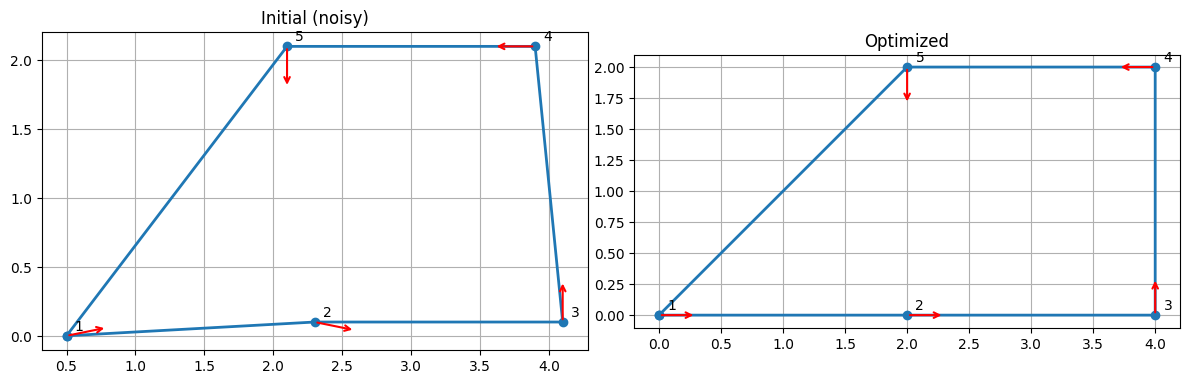

In [7]:
def extract_poses(values, keys):
    return [(values.atPose2(k).x(), values.atPose2(k).y(), values.atPose2(k).theta())
            for k in keys]

keys = [1, 2, 3, 4, 5]
init_poses   = extract_poses(initial, keys)
result_poses = extract_poses(result,  keys)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, poses, title in zip(axes,
                            [init_poses, result_poses],
                            ["Initial (noisy)", "Optimized"]):
    xs = [p[0] for p in poses]
    ys = [p[1] for p in poses]
    ax.plot(xs + [xs[0]], ys + [ys[0]], 'o-', lw=2)
    for i, (x, y, th) in zip(keys, poses):
        ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 4))
        ax.annotate("", xy=(x + 0.3 * math.cos(th), y + 0.3 * math.sin(th)),
                    xytext=(x, y),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()